    240000:
        Este número indica que el archivo emnist-digits-train-images-3-ubyte.gz contiene 240,000 imágenes de entrenamiento.
        Las imágenes representan dígitos del 0 al 9.

    40000:
        Este número indica que el archivo emnist-digits-test-images-idx3-ubyte.gz contiene 40,000 imágenes de prueba.
        Estas imágenes se utilizan para evaluar el modelo después de su entrenamiento.

Para emnist-letters:

    124800:
        Este número indica que el archivo emnist-letters-train-images-idx3-ubyte.gz contiene 124,800 imágenes de entrenamiento.
        Las imágenes representan letras del alfabeto (26 letras en mayúsculas y algunas adicionales, dependiendo del diseño del dataset).

    20800:
        Este número indica que el archivo emnist-letters-test-images-idx3-ubyte.gz contiene 20,800 imágenes de prueba.

<h2>Evaluación del desempeño de SVM en la clasificación de imágenes de perros y gatos - Aprendizaje Automático 2-2024</h2>

* <h5>Nombre: Xavier Muñoz Díaz</h3>
* <h5>Profesora: Violeta Chang Camacho</h3>
* <h5>Ayudante: Marcelo Guzmán</h3>

<h3>Definiciones</h3>

- 

En el laboratorio se utilizan los siguientes parámetros:

<h3>Actividades a desarrollar</h3>

El objetivo de este laboratorio es entender y aplicar redes neuronales para reconocimiento de dígitos y letras manuscritas. Para ello, se utilizarán dos subconjuntos del dataset EMMIST: EMNIST Digits y EMNIST Letters. El primero tiene 10 clases y 280.000 imágenes, mientras que el segundo tiene 27 clases y 145.600 imágenes.

Para llevar a cabo este análisis, se realizarán dos experimentos, en los cuales se deben entrenar 3 modelos MLP que posean entre 2 y 4 capas ocultas, ocupar al menos dos funciones de activación diferentes, ocupar al menos 2 funciones de pérdida diferente y ocupar pesos inicializados al azar.

1) Entrenar 3 MLP con al menos 5 entrenamientos y evaluaciones para cada modelo utilizando el conjunto de datos EMNIST Digits

2) Similar al experimento anterior pero con la diferencia que se utiliza el conjunto de datos EMNIST Letters.

 Los resultados se analizarán en términos de precisión de cada clase en cada modelo apoyados en la matriz de confusión.

<h3>Importaciones de Librerias</h3>

In [1]:
import gzip
import numpy as np
import matplotlib.pyplot as plt
import random
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Nadam, Adam, AdamW
from tensorflow.keras.layers import Input
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, confusion_matrix

<h3>Función de carga de datasets de entrenamiento y prueba con su etiquetado</h3>

In [ ]:
def cargar_datos(ruta_imagenes, ruta_etiquetas):
    with gzip.open(ruta_imagenes, 'rb') as archivo:
        archivo.read(4)  # Número mágico
        cantidad_imagenes = int.from_bytes(archivo.read(4), 'big')
        filas = int.from_bytes(archivo.read(4), 'big')
        columnas = int.from_bytes(archivo.read(4), 'big')
        tamano_imagen = filas * columnas
        imagenes = np.frombuffer(archivo.read(), dtype=np.uint8).reshape(cantidad_imagenes, tamano_imagen)

    with gzip.open(ruta_etiquetas, 'rb') as archivo:
        archivo.read(4)  # Número mágico
        cantidad_etiquetas = int.from_bytes(archivo.read(4), 'big')
        etiquetas = np.frombuffer(archivo.read(), dtype=np.uint8)

    return imagenes/255.0, etiquetas

<h3>Función para cargar el mapping</h3>

In [ ]:
def cargar_mapping(ruta_archivo, dataset="digits"):
    mapping = {}
    with open(ruta_archivo, 'r') as archivo:
        for linea in archivo:
            partes = linea.strip().split()
            if dataset == "letters":
                clave, valor_upper, valor_lower = map(int, partes)
                mapping[clave] = (valor_upper, valor_lower)
            else:  # Para "digits"
                clave, valor = map(int, partes)
                mapping[clave] = valor
    return mapping

<h3>Función para mostrar imágenes de los datasets</h3>

In [ ]:
def mostrar_imagenes_aleatorias(imagenes, etiquetas, mapping, cantidad=20, titulo="Imágenes"):
    """
    Muestra una cantidad dada de imágenes aleatorias junto con sus etiquetas usando el mapping.
    Incluye tanto letras mayúsculas como minúsculas si el mapping contiene tuplas.
    """
    indices = random.sample(range(imagenes.shape[0]), cantidad)
    imagenes_seleccionadas = imagenes[indices]
    etiquetas_seleccionadas = etiquetas[indices]

    filas = int(np.sqrt(cantidad))
    columnas = int(np.ceil(cantidad / filas))

    plt.figure(figsize=(10, 10))
    plt.suptitle(titulo, fontsize=16)
    for i, (imagen, etiqueta) in enumerate(zip(imagenes_seleccionadas, etiquetas_seleccionadas)):
        plt.subplot(filas, columnas, i + 1)
        if etiqueta in mapping:
            if isinstance(mapping[etiqueta], tuple):  # Dataset "letters"
                etiqueta_mapeada = f"{chr(mapping[etiqueta][0])}/{chr(mapping[etiqueta][1])}"  # Uppercase/Lowercase
            else:  # Dataset "digits"
                etiqueta_mapeada = chr(mapping[etiqueta])
        else:
            etiqueta_mapeada = etiqueta
        plt.imshow(imagen.reshape(28, 28), cmap='gray')
        plt.title(f"{etiqueta_mapeada}")
        plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

<h3>Función para la creación de los modelos</h3>

In [4]:
def crear_modelo(capas_ocultas, activacion, loss, optimizador, entradas, salidas):
    modelo = Sequential()
    modelo.add(Input(shape=entradas))  # Usar Input en lugar de input_shape en Flatten
    for capa in capas_ocultas:
        modelo.add(Dense(capa, activation=activacion))
    modelo.add(Dense(salidas, activation="softmax"))
    modelo.compile(optimizer=optimizador, loss=loss, metrics=["accuracy"])
    return modelo

<h3>Función para el entrenamiento y prueba de los modelos</h3>

In [ ]:
def reinicializar_pesos(modelo):
    for layer in modelo.layers:
        if hasattr(layer, 'kernel_initializer') and layer.kernel is not None:
            layer.kernel.assign(layer.kernel_initializer(layer.kernel.shape))
        if hasattr(layer, 'bias_initializer') and layer.bias is not None:
            layer.bias.assign(layer.bias_initializer(layer.bias.shape))
            
def entrenar_y_evaluar_modelos(modelos, x_train, y_train, x_test, y_test):
    resultados = []
    for i, modelo in enumerate(modelos):
        print(f"Entrenando Modelo MLP{i + 1}...")
        acc_totales = []
        acc_clases = []
        matrices_conf = []

        for r in range(5):
            print(f"  Repetición {r + 1}...")
            reinicializar_pesos(modelo)
            modelo.fit(x_train, y_train, epochs=20, batch_size=32, verbose=0)

            predicciones = np.argmax(modelo.predict(x_test), axis=1)
            acc_total = accuracy_score(np.argmax(y_test, axis=1), predicciones)
            matriz_conf = confusion_matrix(np.argmax(y_test, axis=1), predicciones)
            acc_clase = matriz_conf.diagonal() / matriz_conf.sum(axis=1)

            acc_totales.append(acc_total)
            acc_clases.append(acc_clase)
            matrices_conf.append(matriz_conf)

        mediana_acc = np.median(acc_totales)
        resultados.append((mediana_acc, acc_clases[-1], matrices_conf[-1], acc_totales[-1]))

    return resultados

<h2>Experimento 1: Subconjunto EMNIST_Digits</h2>

El subconjunto EMNIST_Digits posee 10 clases las cuales representan un dígito del 0 al 9.

A continuación, se cargan los datos necesarios para el entrenamiento y prueba de los modelos

In [6]:
ruta_digits = "./emnist-digits"
# Concatena la ruta de los archivos con la carpeta de los dígitos con os
ruta_entrenamiento_imagenes = os.path.join(ruta_digits, "emnist-digits-train-images-idx3-ubyte.gz")
ruta_entrenamiento_etiquetas = os.path.join(ruta_digits, "emnist-digits-train-labels-idx1-ubyte.gz")
ruta_prueba_imagenes = os.path.join(ruta_digits, "emnist-digits-test-images-idx3-ubyte.gz")
ruta_prueba_etiquetas = os.path.join(ruta_digits, "emnist-digits-test-labels-idx1-ubyte.gz")
ruta_mapping = os.path.join(ruta_digits, "emnist-digits-mapping.txt")

x_entrenamiento, y_entrenamiento = cargar_datos(ruta_entrenamiento_imagenes, ruta_entrenamiento_etiquetas)
x_prueba, y_prueba = cargar_datos(ruta_prueba_imagenes, ruta_prueba_etiquetas)

mapping = cargar_mapping(ruta_mapping, "digits")

Luego, se muestran de forma aleatoria 20 imágenes tanto para el conjunto de entrenamiento como para el de prueba.

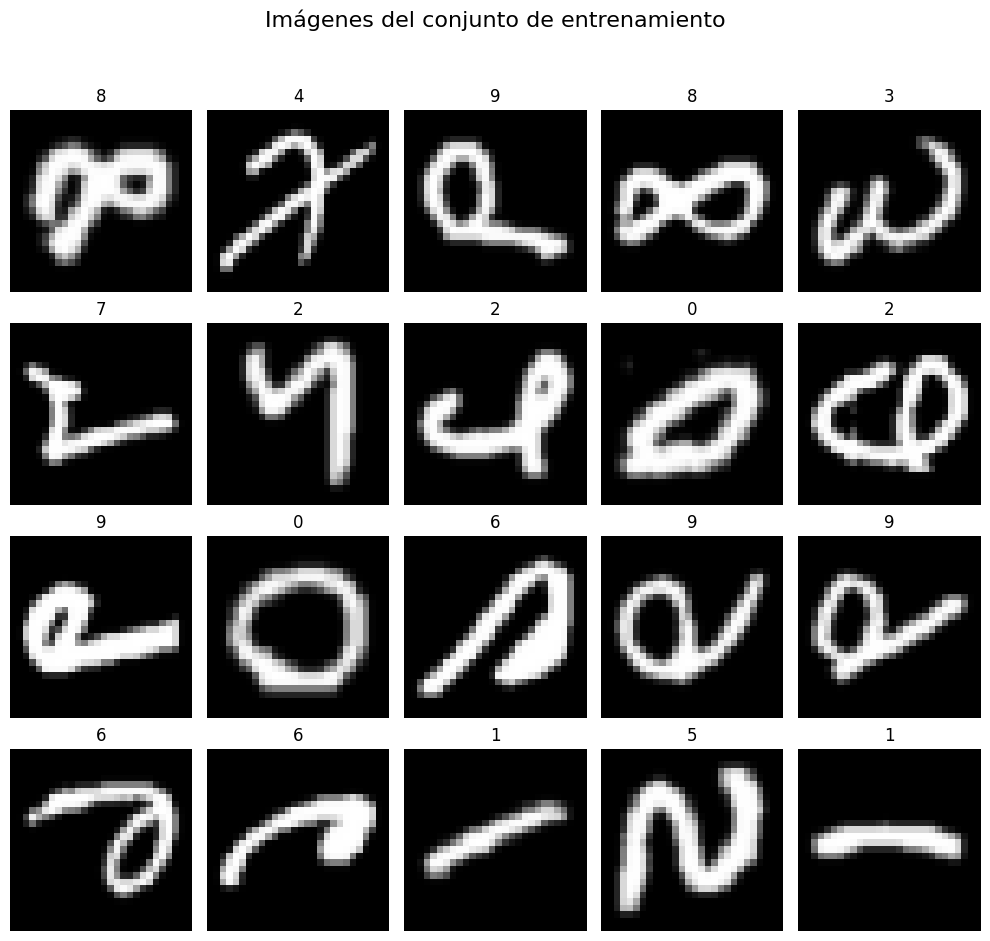

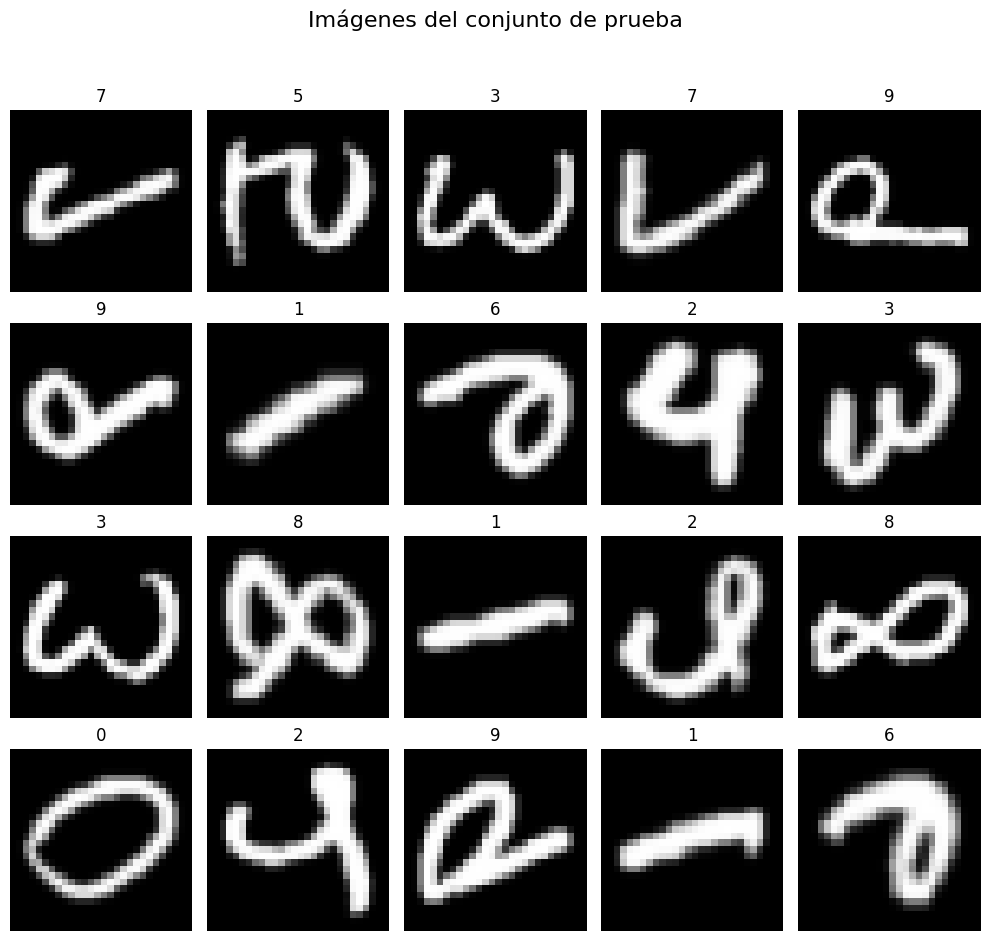

In [7]:
mostrar_imagenes_aleatorias(x_entrenamiento, y_entrenamiento, mapping, cantidad=20, titulo="Imágenes del conjunto de entrenamiento")
mostrar_imagenes_aleatorias(x_prueba, y_prueba, mapping, cantidad=20, titulo="Imágenes del conjunto de prueba")

<h3>Definición y creación de los modelos</h3>

1. El modelo MLP1 utiliza los siguientes parámetros:
    - s
2. El modelo MLP2 utiliza los siguientes parámetros:
    - s
3. El modelo MLP3 utiliza los siguientes parámetros:
    -     s

In [8]:
shape_entrada = (x_entrenamiento.shape[1], )
numero_clases = len(np.unique(y_entrenamiento))

y_entrenamiento_categorico = to_categorical(y_entrenamiento, num_classes=numero_clases)
y_prueba_categorico = to_categorical(y_prueba, num_classes=numero_clases)

parametros_mlp1_exp1 = {'capas_ocultas': [256, 128], 'activacion': 'relu', 'loss': 'categorical_crossentropy'}
parametros_mlp2_exp1 = {'capas_ocultas': [256, 128, 64], 'activacion': 'swish', 'loss': 'categorical_crossentropy'}
parametros_mlp3_exp1 = {'capas_ocultas': [512, 256, 128], 'activacion': 'relu', 'loss': 'categorical_crossentropy'}

MLP1_exp1 = crear_modelo(
    capas_ocultas=parametros_mlp1_exp1['capas_ocultas'],
    activacion=parametros_mlp1_exp1['activacion'],
    loss=parametros_mlp1_exp1['loss'],
    optimizador=Nadam(learning_rate=0.0002),
    entradas=shape_entrada,
    salidas=numero_clases
)

MLP2_exp1 = crear_modelo(
    capas_ocultas=parametros_mlp2_exp1['capas_ocultas'],
    activacion=parametros_mlp2_exp1['activacion'],
    loss=parametros_mlp2_exp1['loss'],
    optimizador=AdamW(learning_rate=0.00015),
    entradas=shape_entrada,
    salidas=numero_clases
)

MLP3_exp1 = crear_modelo(
    capas_ocultas=parametros_mlp3_exp1['capas_ocultas'],
    activacion=parametros_mlp3_exp1['activacion'],
    loss=parametros_mlp3_exp1['loss'],
    optimizador=Adam(learning_rate=0.0002),
    entradas=shape_entrada,
    salidas=numero_clases
)


ENTRENAMIENTO Y PRUEBA MODELOS

In [9]:
resultados = entrenar_y_evaluar_modelos([MLP1_exp1, MLP2_exp1, MLP3_exp1], x_entrenamiento, y_entrenamiento_categorico, x_prueba, y_prueba_categorico)


Entrenando Modelo MLP1...
  Repetición 1...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 2...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 981us/step
  Repetición 3...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 963us/step
  Repetición 4...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
  Repetición 5...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 850us/step
Entrenando Modelo MLP2...
  Repetición 1...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
  Repetición 2...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
  Repetición 3...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 4...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 5...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Entrenando Modelo MLP3...
  Repetición 1...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 2...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 3...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 4...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
  Repetición 5...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

RESULTADOS


Modelo MLP1:
Mediana 5 iteraciones: 0.9887
Accuracy por clase: [0.9915  0.995   0.9945  0.98325 0.98775 0.98475 0.99    0.996   0.96825
 0.988  ]


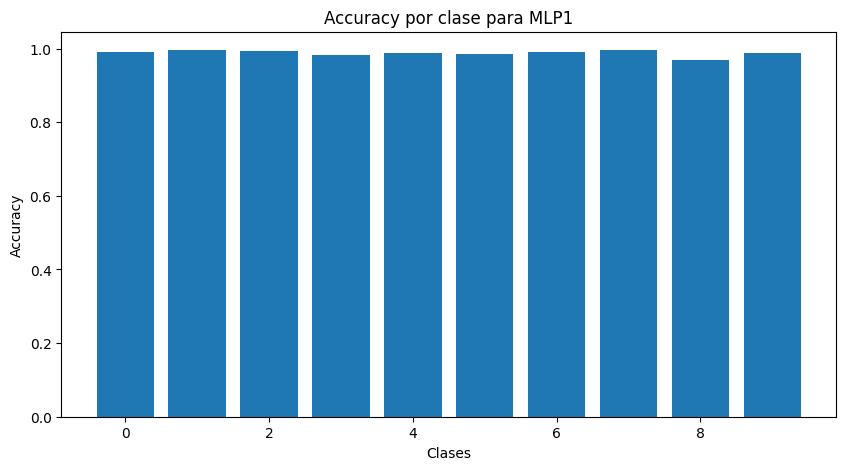

Accuracy total del modelo: 0.9879
Matriz de confusión:
[[3966    4   12    0    4    2    4    2    5    1]
 [   0 3980    7    1    3    0    0    7    2    0]
 [   2    2 3978    8    2    1    1    5    0    1]
 [   3    0   29 3933    0   12    0   10    6    7]
 [   2    3   10    0 3951    0    3    7    3   21]
 [   4    1    2   23    5 3939    8    1   15    2]
 [   9    6    7    0    5    6 3960    0    6    1]
 [   0    2    5    2    3    0    0 3984    0    4]
 [   7   11   37   16    4    8    2   13 3873   29]
 [   0    2    2    7   10    6    1   15    5 3952]]

Modelo MLP2:
Mediana 5 iteraciones: 0.9888
Accuracy por clase: [0.99225 0.99475 0.99    0.97625 0.98575 0.98425 0.99275 0.9915  0.99175
 0.9885 ]


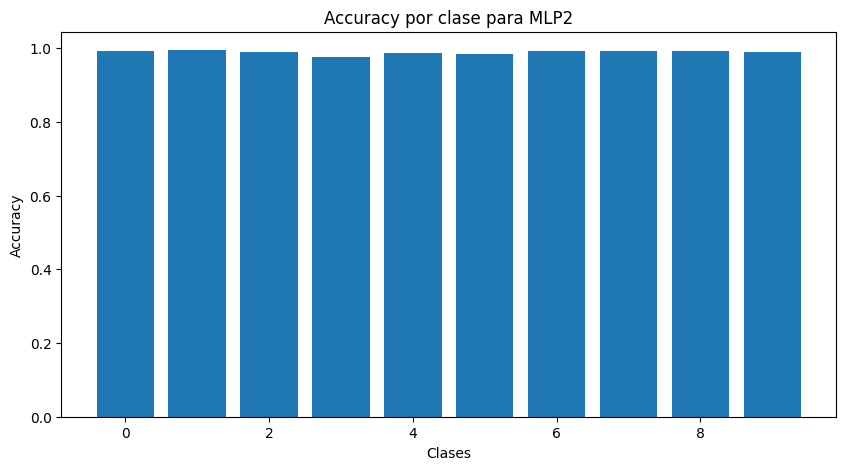

Accuracy total del modelo: 0.988775
Matriz de confusión:
[[3969    0    3    0    1    2   11    0    9    5]
 [   0 3979    4    1    1    0    4    3    7    1]
 [   4    3 3960    6    2    1    1    6   16    1]
 [   3    0   19 3905    0   23    0    9   35    6]
 [   1    4    4    0 3943    1    5    3   11   28]
 [   5    1    2   12    2 3937   12    0   21    8]
 [  10    1    1    0    6    3 3971    0    8    0]
 [   1    1    8    0    5    1    0 3966    5   13]
 [   4    3    6    2    1    3    4    3 3967    7]
 [   0    0    1    2    8    2    0   14   19 3954]]

Modelo MLP3:
Mediana 5 iteraciones: 0.9901
Accuracy por clase: [0.99125 0.996   0.99075 0.97525 0.98925 0.993   0.99075 0.993   0.9815
 0.99375]


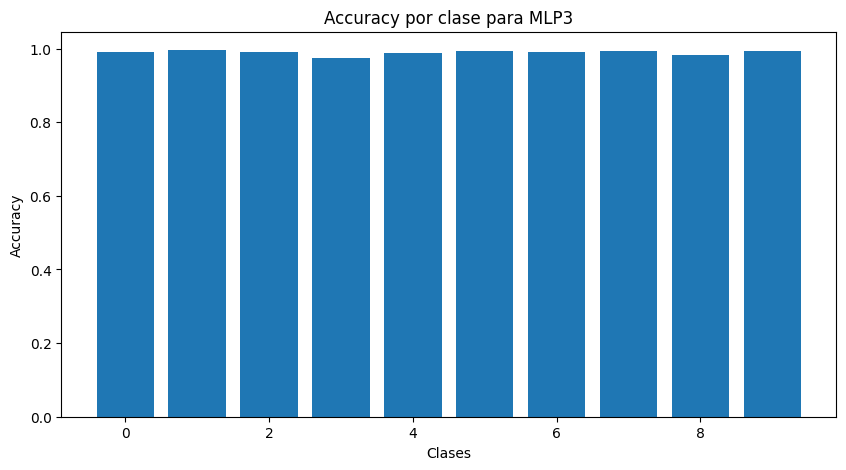

Accuracy total del modelo: 0.98945
Matriz de confusión:
[[3965    3    6    2    1    4    6    0   10    3]
 [   1 3984    4    0    3    2    0    3    2    1]
 [   3    3 3963    9    1    6    0    4    8    3]
 [   1    2   12 3901    0   64    0    5    4   11]
 [   3    3    4    0 3957    0    6    7    2   18]
 [   3    0    0    6    0 3972    4    0   10    5]
 [  10    2    1    0    6   11 3963    0    5    2]
 [   0    1    8    5    4    0    0 3972    0   10]
 [   5    6    4   11    5    7    3    5 3926   28]
 [   0    0    1    2    9    3    0    7    3 3975]]

Mediana Diggits: 0.9888


In [10]:
median_diggits = []
for i, (mediana_acc, acc_clase, matriz_conf, acc_totales) in enumerate(resultados):
    print(f"\nModelo MLP{i + 1}:")
    print(f"Mediana 5 iteraciones: {mediana_acc:.4f}")
    print(f"Accuracy por clase: {acc_clase}")

    plt.figure(figsize=(10, 5))
    plt.bar(range(len(acc_clase)), acc_clase)
    plt.xlabel("Clases")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy por clase para MLP{i + 1}")
    plt.show()

    print(f"Accuracy total del modelo: {acc_totales}")
    print(f"Matriz de confusión:\n{matriz_conf}")
    median_diggits.append(mediana_acc)

print(f"\nMediana Diggits: {np.median(median_diggits):.4f}")


EXPRIMENTO 2

CARGAR DATOS

In [11]:
ruta_letters = "./emnist-letters"
# Concatena la ruta de los archivos con la carpeta de las letras con os
ruta_entrenamiento_imagenes = os.path.join(ruta_letters, "emnist-letters-train-images-idx3-ubyte.gz")
ruta_entrenamiento_etiquetas = os.path.join(ruta_letters, "emnist-letters-train-labels-idx1-ubyte.gz")
ruta_prueba_imagenes = os.path.join(ruta_letters, "emnist-letters-test-images-idx3-ubyte.gz")
ruta_prueba_etiquetas = os.path.join(ruta_letters, "emnist-letters-test-labels-idx1-ubyte.gz")
ruta_mapping = os.path.join(ruta_letters, "emnist-letters-mapping.txt")

x_entrenamiento, y_entrenamiento = cargar_datos(ruta_entrenamiento_imagenes, ruta_entrenamiento_etiquetas)
x_prueba, y_prueba = cargar_datos(ruta_prueba_imagenes, ruta_prueba_etiquetas)

mapping = cargar_mapping(ruta_mapping, "letters")


MOSTRAR IMÁGENES

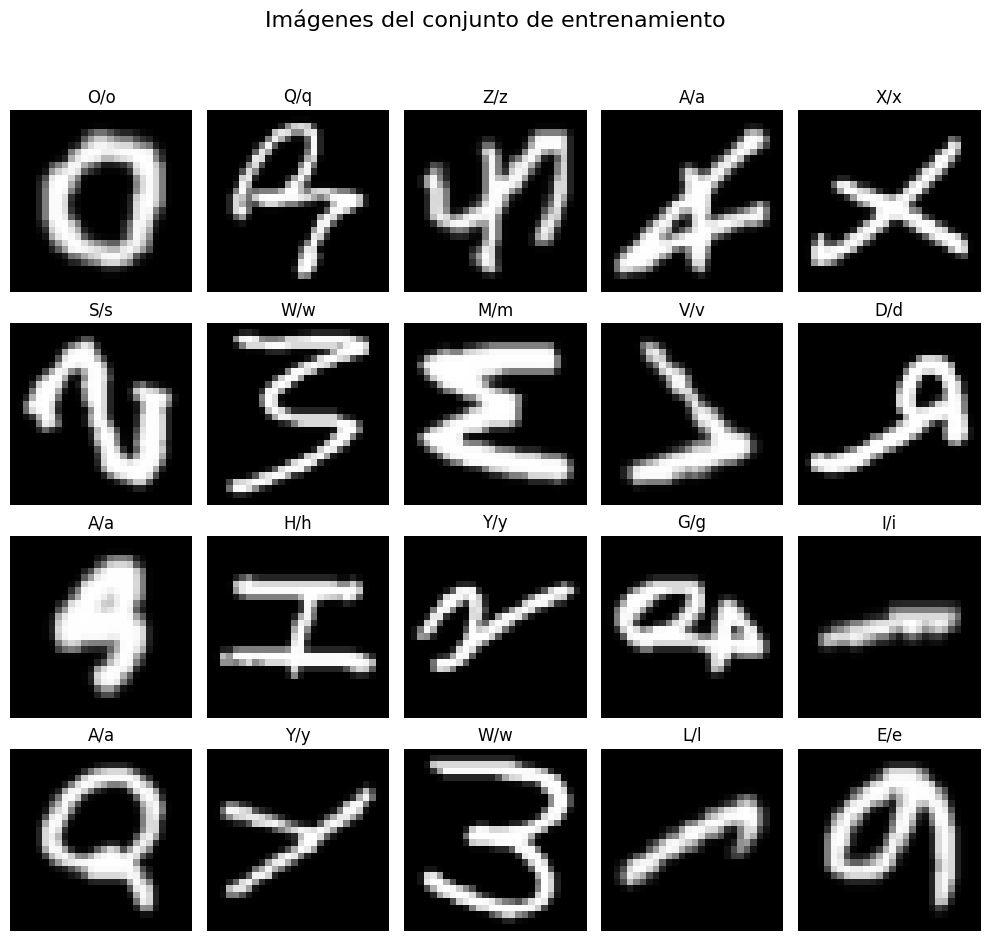

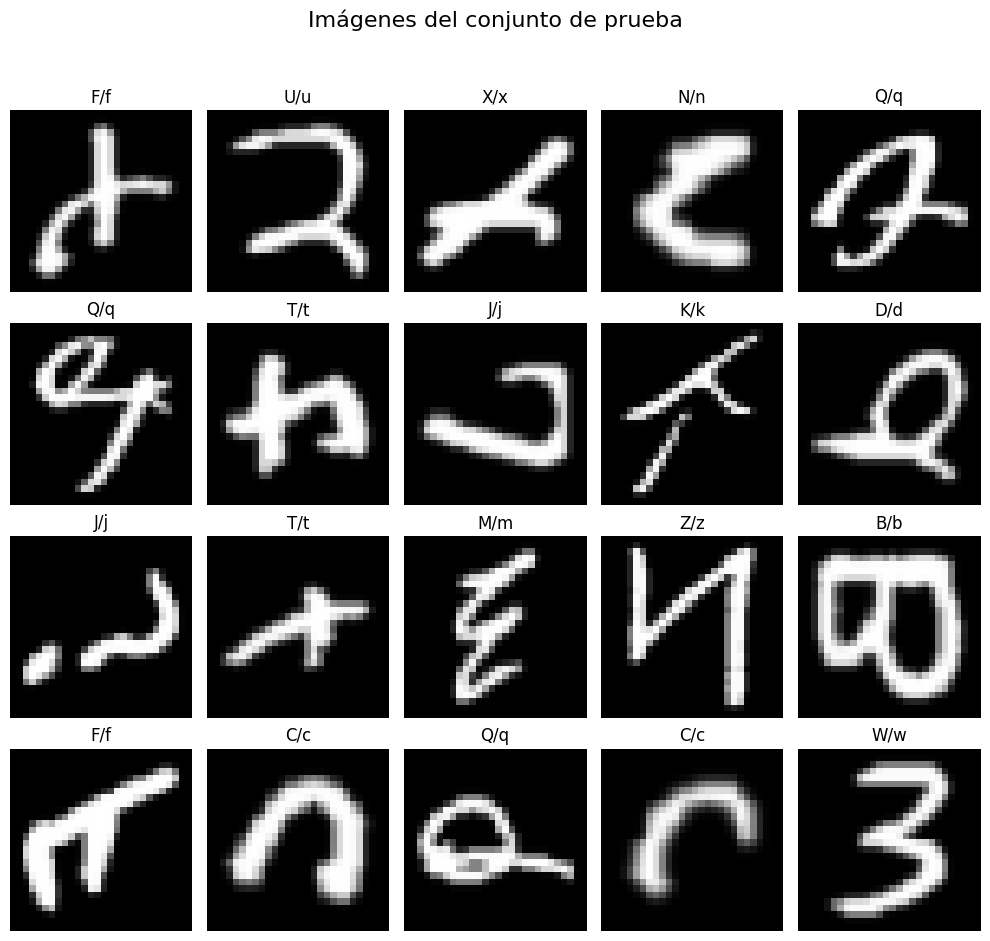

In [12]:
mostrar_imagenes_aleatorias(x_entrenamiento, y_entrenamiento, mapping, cantidad=20, titulo="Imágenes del conjunto de entrenamiento")
mostrar_imagenes_aleatorias(x_prueba, y_prueba, mapping, cantidad=20, titulo="Imágenes del conjunto de prueba")

CREACION MODELOS

In [13]:
shape_entrada = (x_entrenamiento.shape[1], )
numero_clases = len(np.unique(y_entrenamiento))

y_entrenamiento = y_entrenamiento - 1
y_prueba = y_prueba - 1

y_entrenamiento_categorico = to_categorical(y_entrenamiento, num_classes=numero_clases)
y_prueba_categorico = to_categorical(y_prueba, num_classes=numero_clases)

parametros_mlp1_exp2 = {'capas_ocultas': [512, 256], 'activacion': 'relu', 'loss': 'categorical_crossentropy'}
parametros_mlp2_exp2 = {'capas_ocultas': [512, 256, 128], 'activacion': 'relu', 'loss': 'categorical_crossentropy'}
parametros_mlp3_exp2 = {'capas_ocultas': [1024, 512, 128, 64], 'activacion': 'swish', 'loss': 'categorical_crossentropy'}

MLP1_exp2 = crear_modelo(capas_ocultas=parametros_mlp1_exp2['capas_ocultas'], 
                         activacion=parametros_mlp1_exp2['activacion'], 
                         loss=parametros_mlp1_exp2['loss'], 
                         optimizador=Adam(learning_rate=0.0002), 
                         entradas=shape_entrada, 
                         salidas=numero_clases)

MLP2_exp2 = crear_modelo(capas_ocultas=parametros_mlp2_exp2['capas_ocultas'], 
                         activacion=parametros_mlp2_exp2['activacion'], 
                         loss=parametros_mlp2_exp2['loss'], 
                         optimizador=Adam(learning_rate=0.0003), 
                         entradas=shape_entrada, 
                         salidas=numero_clases)

MLP3_exp2 = crear_modelo(capas_ocultas=parametros_mlp3_exp2['capas_ocultas'], 
                         activacion=parametros_mlp3_exp2['activacion'], 
                         loss=parametros_mlp3_exp2['loss'], 
                         optimizador=Nadam(learning_rate=0.0002), 
                         entradas=shape_entrada, 
                         salidas=numero_clases)



ENTRENAMIENTO Y PRUEBA MODELOS

In [14]:
entrenar_y_evaluar_modelos([MLP1_exp2, MLP2_exp2, MLP3_exp2], x_entrenamiento, y_entrenamiento_categorico, x_prueba, y_prueba_categorico)

Entrenando Modelo MLP1...
  Repetición 1...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 2...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 3...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 4...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 5...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Entrenando Modelo MLP2...
  Repetición 1...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 2...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 3...
650/650 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
  Repetición 4...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  Repetición 5...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Entrenando Modelo MLP3...
  Repetición 1...
650/650 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
  Repetición 2...
650/650 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
  Repetición 3...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  Repetición 4...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  Repetición 5...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


[(np.float64(0.9110576923076923),
  array([0.89375, 0.945  , 0.94625, 0.9325 , 0.9525 , 0.92375, 0.71375,
         0.89375, 0.79875, 0.925  , 0.92875, 0.695  , 0.98   , 0.935  ,
         0.95125, 0.96625, 0.87625, 0.93875, 0.965  , 0.93   , 0.8975 ,
         0.9375 , 0.955  , 0.93375, 0.93   , 0.96875]),
  array([[715,   3,   3,  10,   4,   0,   5,   3,   0,   0,   0,   0,   2,
           10,   5,   3,  19,   6,   1,   2,   3,   0,   0,   1,   0,   5],
         [  4, 756,   1,   6,   5,   0,   2,   7,   0,   1,   1,   3,   0,
            1,   3,   0,   5,   1,   0,   0,   0,   0,   0,   0,   0,   4],
         [  1,   1, 757,   3,  23,   0,   1,   0,   0,   0,   0,   4,   0,
            0,   3,   0,   0,   2,   1,   1,   1,   0,   1,   1,   0,   0],
         [  4,   6,   2, 746,   0,   1,   0,   0,   0,   4,   0,   0,   1,
            2,  23,   2,   2,   2,   1,   0,   2,   0,   0,   0,   0,   2],
         [  3,   3,  16,   0, 762,   1,   2,   0,   2,   0,   1,   2,   0,
            0, 

RESULTADOS


Modelo MLP1:
Mediana 5 iteraciones: 0.9887
Accuracy por clase: [0.9915  0.995   0.9945  0.98325 0.98775 0.98475 0.99    0.996   0.96825
 0.988  ]


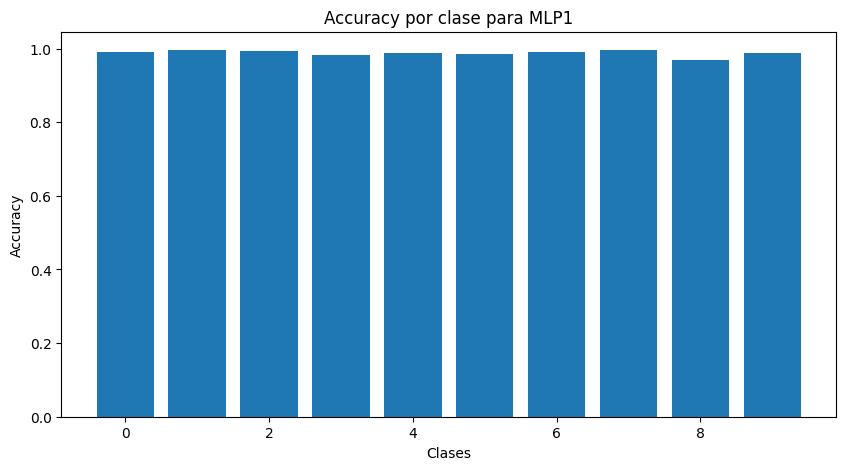

Accuracy total del modelo: 0.9879
Matriz de confusión:
[[3966    4   12    0    4    2    4    2    5    1]
 [   0 3980    7    1    3    0    0    7    2    0]
 [   2    2 3978    8    2    1    1    5    0    1]
 [   3    0   29 3933    0   12    0   10    6    7]
 [   2    3   10    0 3951    0    3    7    3   21]
 [   4    1    2   23    5 3939    8    1   15    2]
 [   9    6    7    0    5    6 3960    0    6    1]
 [   0    2    5    2    3    0    0 3984    0    4]
 [   7   11   37   16    4    8    2   13 3873   29]
 [   0    2    2    7   10    6    1   15    5 3952]]

Modelo MLP2:
Mediana 5 iteraciones: 0.9888
Accuracy por clase: [0.99225 0.99475 0.99    0.97625 0.98575 0.98425 0.99275 0.9915  0.99175
 0.9885 ]


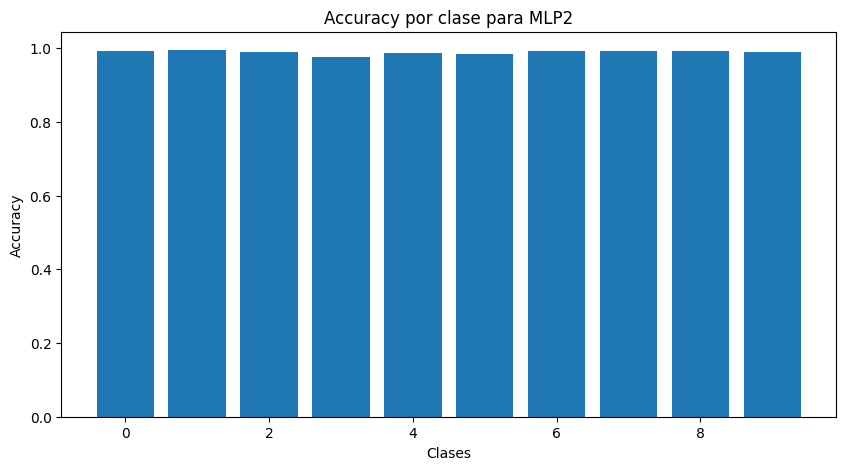

Accuracy total del modelo: 0.988775
Matriz de confusión:
[[3969    0    3    0    1    2   11    0    9    5]
 [   0 3979    4    1    1    0    4    3    7    1]
 [   4    3 3960    6    2    1    1    6   16    1]
 [   3    0   19 3905    0   23    0    9   35    6]
 [   1    4    4    0 3943    1    5    3   11   28]
 [   5    1    2   12    2 3937   12    0   21    8]
 [  10    1    1    0    6    3 3971    0    8    0]
 [   1    1    8    0    5    1    0 3966    5   13]
 [   4    3    6    2    1    3    4    3 3967    7]
 [   0    0    1    2    8    2    0   14   19 3954]]

Modelo MLP3:
Mediana 5 iteraciones: 0.9901
Accuracy por clase: [0.99125 0.996   0.99075 0.97525 0.98925 0.993   0.99075 0.993   0.9815
 0.99375]


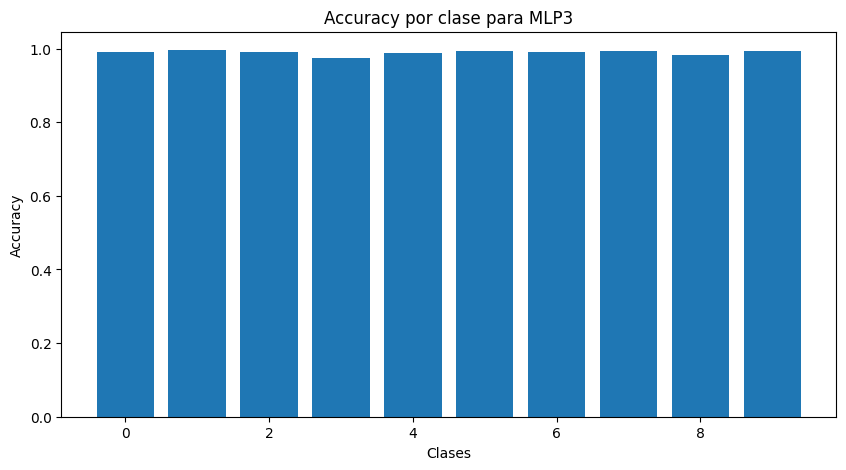

Accuracy total del modelo: 0.98945
Matriz de confusión:
[[3965    3    6    2    1    4    6    0   10    3]
 [   1 3984    4    0    3    2    0    3    2    1]
 [   3    3 3963    9    1    6    0    4    8    3]
 [   1    2   12 3901    0   64    0    5    4   11]
 [   3    3    4    0 3957    0    6    7    2   18]
 [   3    0    0    6    0 3972    4    0   10    5]
 [  10    2    1    0    6   11 3963    0    5    2]
 [   0    1    8    5    4    0    0 3972    0   10]
 [   5    6    4   11    5    7    3    5 3926   28]
 [   0    0    1    2    9    3    0    7    3 3975]]

Mediana Letters: 0.9888


In [15]:
median_diggits = []
for i, (mediana_acc, acc_clase, matriz_conf, acc_totales) in enumerate(resultados):
    print(f"\nModelo MLP{i + 1}:")
    print(f"Mediana 5 iteraciones: {mediana_acc:.4f}")
    print(f"Accuracy por clase: {acc_clase}")

    plt.figure(figsize=(10, 5))
    plt.bar(range(len(acc_clase)), acc_clase)
    plt.xlabel("Clases")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy por clase para MLP{i + 1}")
    plt.show()

    print(f"Accuracy total del modelo: {acc_totales}")
    print(f"Matriz de confusión:\n{matriz_conf}")
    median_diggits.append(mediana_acc)

print(f"\nMediana Letters: {np.median(median_diggits):.4f}")